### Corrective RAG (CRAG)
<img src="../imgs/img_crag.webp" alt="My diagram" width="800">

## Overview

**Corrective Retrieval Augmented Generation (CRAG)** is proposed to enhance the robustness of generation when errors in retrieval are introduced.

## Key Components

### Retrieval Evaluator

A lightweight retrieval evaluator that:
- Assesses the overall quality of retrieved documents
- Provides a confidence degree/score for the retrieved results
- Triggers different knowledge retrieval actions based on confidence levels

## How It Works

1. **Assess** — Evaluate the quality of retrieved documents
2. **Score** — Generate a confidence metric
3. **Action** — Based on confidence:
   - High confidence → Use retrieved documents for generation
   - Low confidence → Re-retrieve, broaden search, or use fallback strategy

## Benefits

- ✓ Enhances robustness against retrieval errors
- ✓ Reduces hallucinations with low-quality sources
- ✓ Provides adaptive retrieval strategies
- ✓ Improves generation reliability

In [1]:
import os
from huggingface_hub import InferenceClient
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_openai import ChatOpenAI


c:\python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["HUGGINGFACE_API_KEY"] = os.getenv("HUGGINGFACE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [3]:
# llm = InferenceClient(
#     api_key=os.environ["HUGGINGFACE_API_KEY"],
# )

embedding = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10305.42it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
llm = ChatOpenAI(
    # Point to the OpenAI-compatible "door"
    base_url="http://localhost:11434/v1", 
    
    # Required but ignored by Ollama
    api_key="ollama", 
    
    # The exact name you see in 'ollama list'
    model="qwen2.5:1.5b", 
    
    temperature=0
)

In [ ]:
# print(llm.invoke("What is the time complexity of Merge Sort?").content)

The time complexity of Merge Sort is O(n log n). This means that as the size of the input list increases, the time it takes to sort the list grows logarithmically with respect to its size.

Here's a brief explanation:

1. **Merge Sort Algorithm**:
   - The algorithm divides the array into two halves until each subarray contains only one element.
   - Then, it merges these sorted subarrays back together in a sorted manner.

2. **Time Complexity Analysis**:
   - Each merge operation takes O(n) time because merging involves comparing and combining elements from both subarrays.
   - The number of merge operations is proportional to the height of the recursion tree, which is log n (since each level reduces the problem size by half).
   - Therefore, the overall time complexity is O(n * log n).

3. **Space Complexity**:
   - Merge Sort requires additional space for merging subarrays.
   - The space complexity is O(n) due to the temporary storage needed during the merge process.

In summary, w

#### Lets Create A Retrieval Now

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [6]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, chunk_overlap=20
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embedding,
)
retriever = vectorstore.as_retriever(k = 4)

#### Lets Create A RAG chain now

In [7]:
from langchain_core.output_parsers import StrOutputParser

In [8]:
from langchain_core.prompts import PromptTemplate

# Prompt
prompt = PromptTemplate(
    template='''You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer: ''',
    input_variables=["question", "context"]
)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) # Extract the text content from each document and join them with newlines


# Chain
rag_chain = prompt | llm | StrOutputParser()

In [9]:
question = "tell me about agent memory."
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

The text discusses various methods and techniques for defending language models (LLMs) against adversarial attacks, including:

1. **Robustness to Adversarial Attacks**:
   - The text mentions that larger model capacity is needed to increase robustness.
   - It also notes that explicitly instructing the model not to generate harmful content can reduce jailbreak attack success rates but may negatively impact general model quality.

2. **Preprocessing Text Inputs**:
   - Paraphrasing input text using LLMs can cause small impacts on downstream tasks' performance.
   - Retokenization, where tokens are broken apart and represented with multiple smaller tokens, helps degrade the attack success rate but is limited in effectiveness (e.g., 90% down to 40%).

3. **Adversarial Training**:
   - The text mentions two adversarial training setups by Jain et al. 2023: 
     1. Running gradient descent on harmful prompts paired with "I'm sorry" responses.
     2. Running one descent step on a refusal r

#### Document Grader

In [11]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

In [12]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [13]:
# Using Structured Output Pattern to get a binary score for relevance of retrieved documents to the user question.
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

In [16]:
question = "tell me about the Tajmahal."
docs1 = retriever.invoke(question)
doc_txt1 = docs1[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt1}))

binary_score='no'


#### Question Re-Writer

In [17]:
from langchain_core.prompts import ChatPromptTemplate

system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
     
     
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

#### Now Create node/function for CRAG

In [18]:
def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
    
    """
    print("---RETRIEVE---")
    
    question = state["question"]
    
    documents = retriever.invoke(question)
    
    return {"documents": documents, "question": question}

In [19]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """
    
    print("---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---")
    
    question = state["question"]
    
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    
    web_search = "No"
    
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

In [20]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    
    print("---GENERATE---")
    
    question = state["question"]
    documents = state["documents"]
    
    generation = rag_chain.invoke({"context": documents, "question": question})
    
    return {"documents": documents, "question": question, "generation": generation}

In [21]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    
    question = state["question"]
    
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    
    return {"documents": documents, "question": better_question}

#### For Web Search

In [22]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k=3)

C:\Users\Manas tiwari\AppData\Local\Temp\ipykernel_28492\2239647488.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


In [24]:
from langchain_core.documents import Document

def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """
    print("---WEB SEARCH---")
    
    question = state["question"]
    
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    
    web_results = "\n".join([d["content"] for d in docs])
    
    web_results = Document(page_content=web_results)
    
    documents.append(web_results)  # Appending web search results to retrieved documents

    return {"documents": documents, "question": question}

In [25]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """
    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

#### Graph for CRAG

In [26]:
from langgraph.graph import END, StateGraph, START
from typing import List
from typing_extensions import TypedDict


In [27]:
class State(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [28]:
workflow= StateGraph(State)

workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generatae
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

workflow.add_conditional_edges("grade_documents", decide_to_generate, {"transform_query": "transform_query","generate": "generate",}),

(<langgraph.graph.state.StateGraph at 0x1d747d3e270>,)

In [29]:
app = workflow.compile()

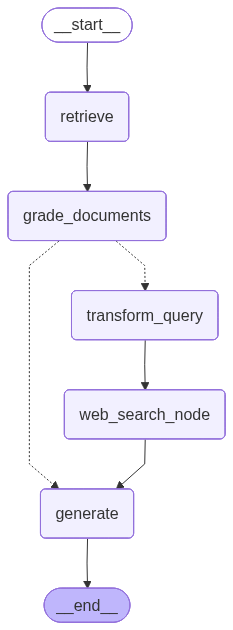

In [30]:
display(app)

In [31]:
from pprint import pprint

In [32]:
inputs = {"question": "tell me about the agent memory."}

In [ ]:
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")

pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
"Node 'grade_documents':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('In a LLM-powered autonomous agent system, the memory component plays a '
 'crucial role by providing long-term retention and recall capabilities for '
 'information over extended periods. This is achieved through short-term '
 'memory that leverages in-context learning from past interactions with the '
 'model, as well as long-term memory that can store and retrieve vast amounts '
 'of data using external vector stores and fast retrieval mechanisms. The '
 "agent's ability to retain and recall this information allows it to adapt to "
 'new situations by drawing upon its previous experiences and knowledge.')


In [34]:
inputs = {"question": "tell me about the taj mahal."}

In [35]:
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    pprint("\n---\n")
    
pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"
'\n---\n'
---CHECKING DOCUMENT RELEVANT IS TO QUESTION OR NOT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
"Node 'grade_documents':"
'\n---\n'
---TRANSFORM QUERY---
"Node 'transform_query':"
'\n---\n'
---WEB SEARCH---
"Node 'web_search_node':"
'\n---\n'
---GENERATE---
"Node 'generate':"
'\n---\n'
('The Taj Mahal is a white marble mausoleum located on the right bank of the '
 'Yamuna River in Agra, India. It was commissioned by Mughal emperor Shah '
 'Jahan to immortalize his favorite wife Mumtaz Mahal, who died in childbirth '
 "in 1631. The structure's fame is not only due to its beautiful design but "
 'also because it attracts millions of tourists each year as one of the '
 "world's most iconic monuments.")
